# CSE620 Project 1
## Fall 2026

## Liam, Jack, David

In [1]:
from methods import newtons_method, gradient_descent, adagrad, adam
from utilities import plot_contours_with_path

import numpy as np
import pandas as pd
from sympy import Symbol, Add, lambdify, cos
from typing import Tuple, Iterable

## Defining functions and choosing starting points

It would be nice to pass simpler types and then convert to np.array within the functions.

In [2]:
x1 = Symbol('x1')
x2 = Symbol('x2')

symbols = (x1, x2)
quadratic_function = x1**2 + x2**2
quadratic_starting_points = [np.array([1, 2]), np.array([-3, 4]), np.array([-5, -6]), np.array([7, -8])]

banana_valley_function = (1 - x1)**2 + 100*(x2 - x1**2)**2
banana_valley_starting_points = [np.array([1, 2]), np.array([-3, 4]), np.array([-5, -6]), np.array([7, -8])]

cosine_bumps_function = x1**2 + x2**2 + 10*cos(x1) + 10*cos(x2)
cosine_bumps_starting_points = [np.array([1, 2]), np.array([-3, 4]), np.array([-5, -6]), np.array([7, -8])]

## ADAM results demonstration.
Need to clean this up and do it for the rest of the methods.

In [3]:
results =[]
adam_results = []
gradient_descent_results = []
adagrad_results = []
newtons_method_results = []

for starting_point in cosine_bumps_starting_points:
    adam_results.append(adam((x1, x2), 
                    cosine_bumps_function, 
                    starting_point,
                    ((-9999, 9999), (-9999, 9999)),
                    0.1,
                    0.9,
                    0.999
                    ))

    gradient_descent_results.append(gradient_descent((x1, x2), 
                                    cosine_bumps_function, 
                                    starting_point,
                                    ((-9999, 9999), (-9999, 9999)),
                                    0.1))

    adagrad_results.append(adagrad((x1, x2), 
                           cosine_bumps_function, 
                           starting_point,
                           ((-9999, 9999), (-9999, 9999)),
                           0.1))

    newtons_method_results.append(newtons_method((x1, x2), 
                                  cosine_bumps_function, 
                                  starting_point,
                                  ((-10, 10), (-10, 10))))

    results = adam_results + gradient_descent_results + adagrad_results + newtons_method_results

Newton's method cannot handle this function. It is the only one with tight bounds.

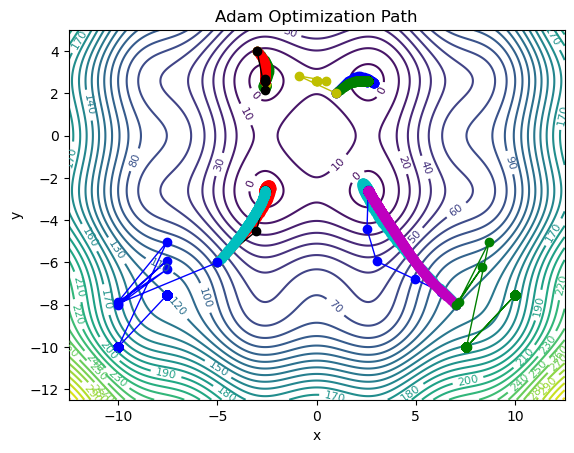

In [4]:
from utilities import plot_contours_with_path
plot_contours_with_path((x1, x2), 
                        cosine_bumps_function, results, 
                        title="Adam Optimization Path",
                    
)

We need a way to better control this plot, such as adding a legend. I think using keyword arguments could work.

We should also reduce the size or change the shape of the path points, and not use "cool" colors like light blue or cyan, as they are blending in with the topo lines too much.

In [ ]:
from utilities import test_optimizer

step_sizes = list(np.array(range(1, 101))/100)
starting_point = cosine_bumps_starting_points[0]
step_size, starting_points, final_value, number_of_iterations = test_optimizer(
    optimizer_name="adam",
    step_size=step_size,
    starting_point=starting_point,
    beta1=0.9,
    beta2=0.999,
    x_symbols=symbols,
    f_symbolic=cosine_bumps_function,
    bounds=((-9999, 9999), (-9999, 9999))
)

df = pd.DataFrame({
    "Step Size": step_size,
    "Starting Point": starting_points,
    "Final Value": final_value,
    "Number of Iterations": number_of_iterations
})

df

,Step Size,Starting Point,Final Value,Number of Iterations
0,0.01,"[1, 2]",-3.617967,397
1,0.02,"[1, 2]",-3.617967,238
2,0.03,"[1, 2]",-3.617967,224
3,0.04,"[1, 2]",-3.617967,228
4,0.05,"[1, 2]",-3.617967,216
...,...,...,...,...
95,0.96,"[1, 2]",-3.617967,247
96,0.97,"[1, 2]",-3.617967,239
97,0.98,"[1, 2]",-3.617967,257
98,0.99,"[1, 2]",-3.617967,240


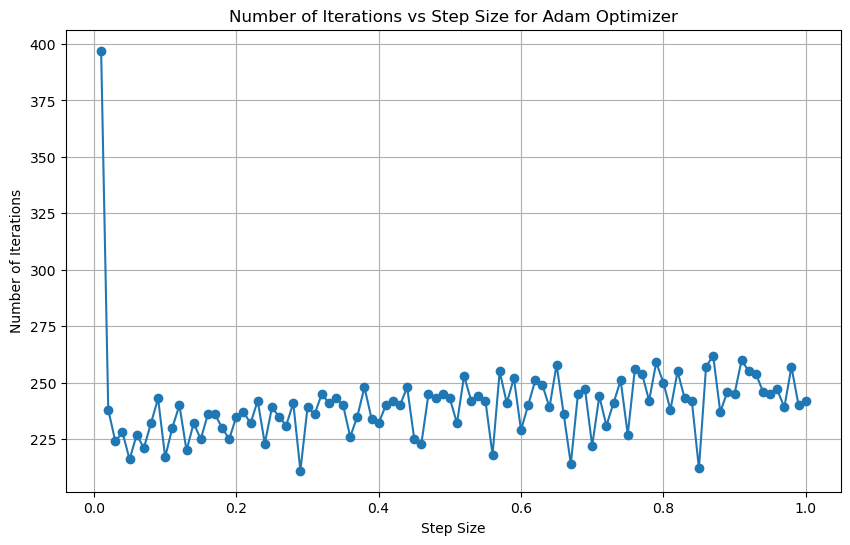

In [9]:
#plot the dataframe
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(step_size, number_of_iterations, marker='o', linestyle='-')
plt.xlabel('Step Size')
plt.ylabel('Number of Iterations')
plt.title('Number of Iterations vs Step Size for Adam Optimizer')
plt.grid(True)
plt.show()